In [25]:
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
from collections import Counter, defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
import hdbscan


# Load the small English model
nlp = spacy.load("en_core_web_sm")


# Input text

In [5]:

# Process the text
text = ["The consultant team were really responsive to my questions.  Several different doctors explained things when I couldn't speak to my consultant. Please send my compliments to the team.",
        "The nursing staff were too busy.  When I pressed the call bell, it took a long time for someone to come.  I had to wait for ages before I got any help with my pain, and going to the toilet.  When I didn't get my pain medication on time, I couldn't even get out of bed to go to the toilet, and I had an accident.  I was really embarrassed and upset about that.  I wish the staff had been able to help me sooner.",
        "The food was really bad.  Mum doesn't eat much at the best of times, but the food was so bad that she hardly ate anything at all.  How is she going to get better if she doesn't have the basics like food and water?  I don't understand how the hospital can let patients go hungry like that.  It's really unacceptable.",
        "I was skeptical about using the app to book my appointment, but it was actually really easy to use.  I was able to find a time that worked for me and book my appointment in just a few clicks.  I wasn't waiting on letters that arrive too late, and I knew I wasn't lost in the system.  It's a big improvment.",
        "The time I waited for an appointment was a joke.  Why does it take so long to get an appointment?  I had to wait for months before I could see a doctor, and when I finally got an appointment, it was cancelled at the last minute.  It's really frustrating and unacceptable.  I don't understand why the healthcare system can't do better than this.",
        "The staff were really kind and helpful.  They went out of their way to make sure I was comfortable and had everything I needed.  I felt like they really cared about me and my wellbeing, and that made a big difference in my experience at the hospital.  I'm really grateful for their kindness and support.",
        "Dad was really impressed with the care he received.  The doctors and nurses were really knowledgeable and professional, and they made sure to explain everything to him in a way that he could understand.  He felt like he was in good hands, and that gave him a lot of confidence in his treatment.  He's really grateful for the care he received.",
        "Dad doesn't speak English.  It's ok when I can be with him in the hospital, but I can't be there all the time as I've got kids and a job.  The hospital said they could provider and interpreter, but we didn't get one for the first few days, and when we did get one, they weren't very good.  They didn't understand Dad's accent, and they kept getting things wrong.  It was really frustrating and made it hard for Dad to communicate with the staff.  I wish the hospital had been able to provide better support for non-English speakers.",
        "I didn't understand what the doctors were saying.  They used a lot of medical jargon that I didn't understand, and they didn't take the time to explain things in a way that I could understand.  I felt really confused and overwhelmed, and it made it hard for me to make informed decisions about my care.  I wish the doctors had been able to communicate more clearly with me.",
        "I'm really angry that I was sent home so early.  I didn't feel ready to go home, and I felt like the hospital was just trying to get rid of me.  I had a lot of questions and concerns about my care, but the staff didn't take the time to address them.  I felt really abandoned and unsupported, and it made my recovery much harder than it needed to be.  I wish the hospital had been able to provide better support for patients who are being discharged."
        "I was sat in a corridor for nearly 2 days.  I was in pain, on my own, and it was very undignified.  I felt sorry for the staff, who were clearly overwhelmed, but I wish they had been able to find a better solution for me.  Why doesn't the hospital open more beds?"
]

#doc = nlp(text)


# Pulling out key words

In [6]:
keywords = []

for doc in nlp.pipe(text):
    keywords.extend([
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct
    ])

for item in keywords:
    print(item)


consultant
team
responsive
question
 
different
doctor
explain
thing
speak
consultant
send
compliment
team
nursing
staff
busy
 
press
bell
take
long
time
come
 
wait
age
get
help
pain
go
toilet
 
pain
medication
time
bed
toilet
accident
 
embarrassed
upset
 
wish
staff
able
help
soon
food
bad
 
Mum
eat
good
time
food
bad
hardly
eat
 
go
well
basic
like
food
water
 
understand
hospital
let
patient
hungry
like
 
unacceptable
skeptical
app
book
appointment
actually
easy
use
 
able
find
time
work
book
appointment
click
 
wait
letter
arrive
late
know
lose
system
 
big
improvment
time
wait
appointment
joke
 
long
appointment
 
wait
month
doctor
finally
get
appointment
cancel
minute
 
frustrating
unacceptable
 
understand
healthcare
system
well
staff
kind
helpful
 
go
way
sure
comfortable
need
 
feel
like
care
wellbeing
big
difference
experience
hospital
 
grateful
kindness
support
Dad
impressed
care
receive
 
doctor
nurse
knowledgeable
professional
sure
explain
way
understand
 
feel
like
goo

## Quick topic modelling

In [7]:
all_words = []

for doc in nlp.pipe(text):
    all_words.extend([
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct
    ])

word_freq = Counter(all_words)

print(word_freq.most_common(20))

[(' ', 38), ('time', 8), ('hospital', 8), ('understand', 7), ('staff', 6), ('able', 6), ('feel', 6), ('doctor', 5), ('wish', 5), ('well', 5), ('like', 5), ('appointment', 5), ('care', 5), ('wait', 4), ('get', 4), ('dad', 4), ('explain', 3), ('thing', 3), ('pain', 3), ('go', 3)]


## More advanced:  LDA topic modelling

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(text)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"Topic {i}:")
    print([words[j] for j in topic.argsort()[-10:]])

Topic 0:
['wellbeing', 'went', 'support', 'like', 'needed', 'big', 'way', 'grateful', 'sure', 'really']
Topic 1:
['understand', 'unacceptable', 'don', 'bad', 'better', 'doesn', 'like', 'food', 'really', 'appointment']
Topic 2:
['care', 'better', 'staff', 'able', 'wish', 'didn', 'dad', 'felt', 'really', 'hospital']
Topic 3:
['team', 'consultant', 'couldn', 'book', 'wasn', 'toilet', 'help', 'pain', 'really', 'time']
Topic 4:
['overwhelmed', 'lot', 'communicate', 'hard', 'explain', 'way', 'things', 'doctors', 'didn', 'understand']


## Visualisation:

### Bar charts

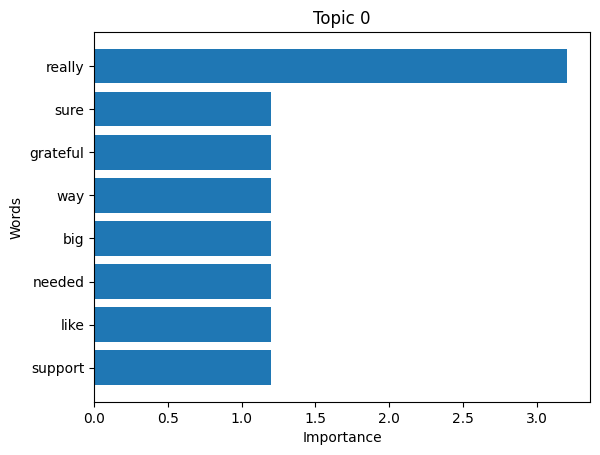

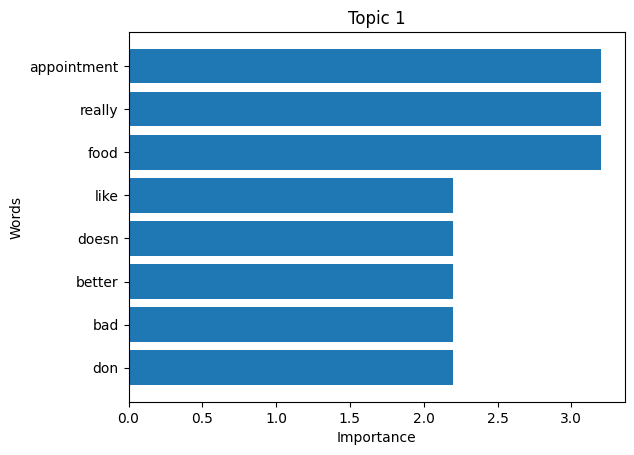

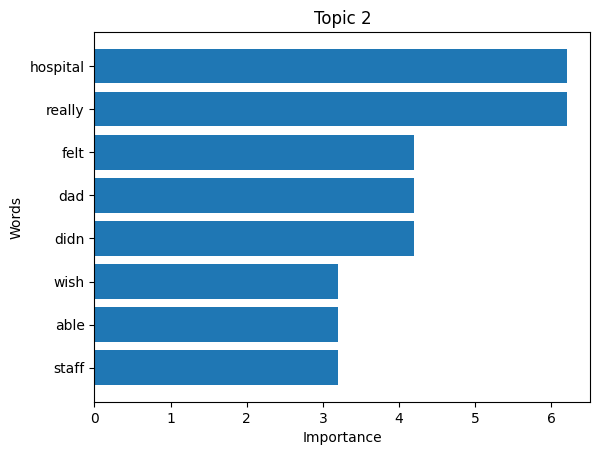

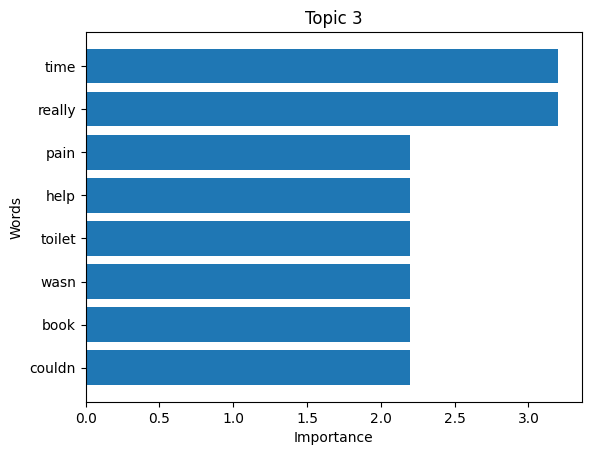

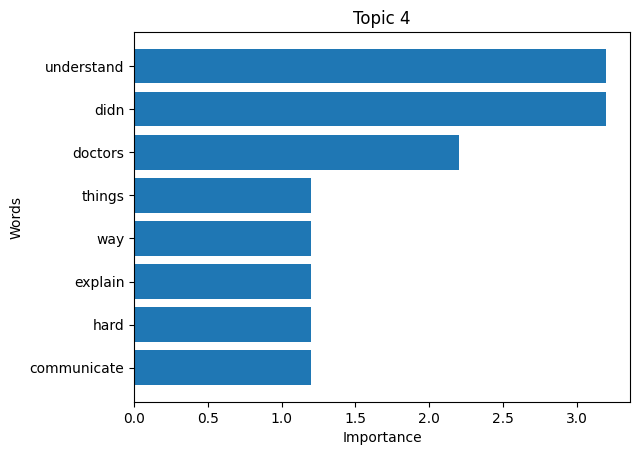

In [9]:
n_top_words = 8

for topic_idx, topic in enumerate(lda.components_):
    top_features_idx = topic.argsort()[-n_top_words:]
    top_features = [words[i] for i in top_features_idx]
    weights = topic[top_features_idx]

    plt.figure()
    plt.barh(top_features, weights)
    plt.title(f"Topic {topic_idx}")
    plt.xlabel("Importance")
    plt.ylabel("Words")
    plt.show()

### Word cloud:

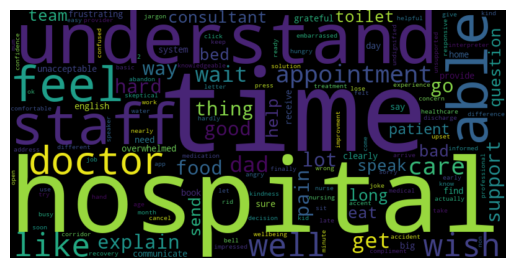

In [10]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_freq)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [11]:
doc_topic_dist = lda.transform(X)

df_topics = pd.DataFrame(
    doc_topic_dist,
    columns=[f"Topic {i}" for i in range(lda.n_components)]
)

print(df_topics)

    Topic 0   Topic 1   Topic 2   Topic 3   Topic 4
0  0.012544  0.012530  0.012592  0.949693  0.012641
1  0.006079  0.006097  0.006125  0.975588  0.006112
2  0.006935  0.972274  0.006964  0.006912  0.006915
3  0.007437  0.007453  0.007434  0.970254  0.007421
4  0.008712  0.965026  0.008745  0.008780  0.008736
5  0.966449  0.008375  0.008444  0.008366  0.008366
6  0.007522  0.007458  0.970021  0.007436  0.007564
7  0.004559  0.004578  0.981690  0.004575  0.004598
8  0.006495  0.006480  0.006554  0.006497  0.973974
9  0.003469  0.003467  0.986115  0.003473  0.003476


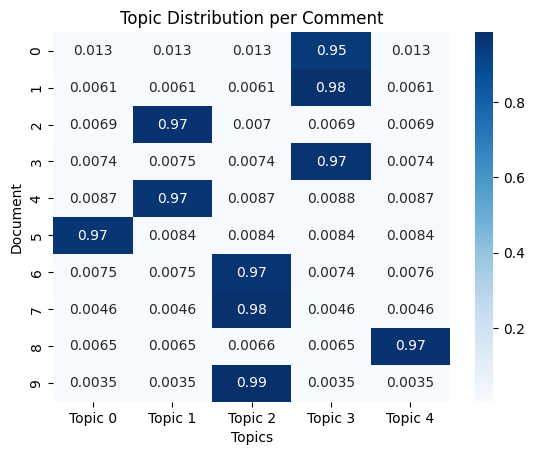

In [12]:
sns.heatmap(df_topics, annot=True, cmap="Blues")
plt.title("Topic Distribution per Comment")
plt.xlabel("Topics")
plt.ylabel("Document")
plt.show()

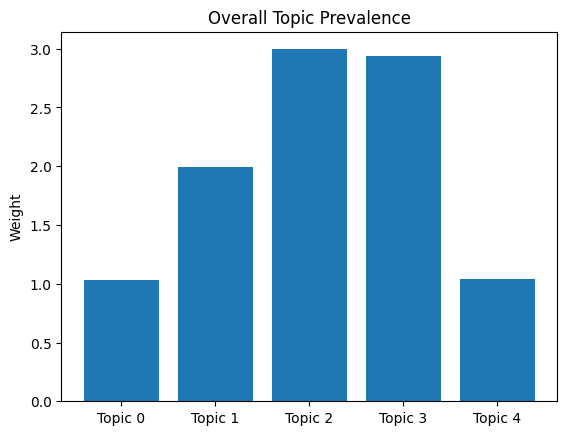

In [13]:
topic_totals = doc_topic_dist.sum(axis=0)

plt.bar([f"Topic {i}" for i in range(len(topic_totals))], topic_totals)
plt.title("Overall Topic Prevalence")
plt.ylabel("Weight")
plt.show()


## Sentiment analysis example:

In [14]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyser = SentimentIntensityAnalyzer()

for t in text:
    scores = analyser.polarity_scores(t)
    print(t[:50])
    print(scores)
    print()


The consultant team were really responsive to my q
{'neg': 0.0, 'neu': 0.762, 'pos': 0.238, 'compound': 0.7778}

The nursing staff were too busy.  When I pressed t
{'neg': 0.121, 'neu': 0.771, 'pos': 0.108, 'compound': -0.3082}

The food was really bad.  Mum doesn't eat much at 
{'neg': 0.165, 'neu': 0.671, 'pos': 0.164, 'compound': -0.2785}

I was skeptical about using the app to book my app
{'neg': 0.025, 'neu': 0.874, 'pos': 0.101, 'compound': 0.7255}

The time I waited for an appointment was a joke.  
{'neg': 0.153, 'neu': 0.816, 'pos': 0.031, 'compound': -0.8254}

The staff were really kind and helpful.  They went
{'neg': 0.0, 'neu': 0.631, 'pos': 0.369, 'compound': 0.9775}

Dad was really impressed with the care he received
{'neg': 0.0, 'neu': 0.688, 'pos': 0.312, 'compound': 0.9722}

Dad doesn't speak English.  It's ok when I can be 
{'neg': 0.116, 'neu': 0.776, 'pos': 0.108, 'compound': -0.232}

I didn't understand what the doctors were saying. 
{'neg': 0.052, 'neu': 0.812, 'po

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2123.96it/s]


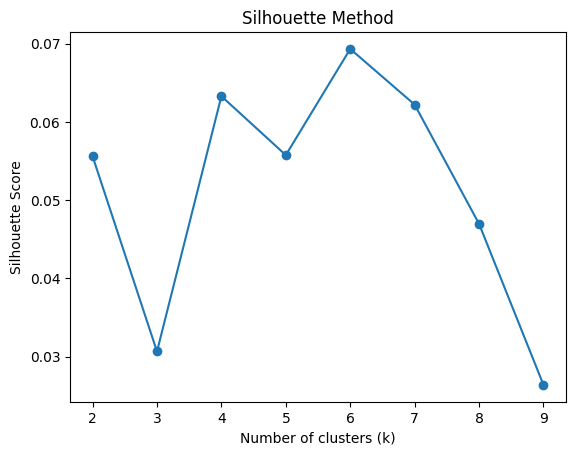

Best k: 6 (score=0.069)
Text: The consultant team were really responsive to my questions. ...
Cluster: 2

Text: The nursing staff were too busy.  When I pressed the call be...
Cluster: 1

Text: The food was really bad.  Mum doesn't eat much at the best o...
Cluster: 5

Text: I was skeptical about using the app to book my appointment, ...
Cluster: 0

Text: The time I waited for an appointment was a joke.  Why does i...
Cluster: 1

Text: The staff were really kind and helpful.  They went out of th...
Cluster: 3

Text: Dad was really impressed with the care he received.  The doc...
Cluster: 3

Text: Dad doesn't speak English.  It's ok when I can be with him i...
Cluster: 4

Text: I didn't understand what the doctors were saying.  They used...
Cluster: 2

Text: I'm really angry that I was sent home so early.  I didn't fe...
Cluster: 1



In [33]:
# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert text → embeddings
embeddings = model.encode(text)

scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    scores.append(score)

# Plot
plt.plot(K_range, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()


best_k = None
best_score = -1

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(embeddings)

    score = silhouette_score(embeddings, labels)

    if score > best_score:
        best_score = score
        best_k = k

print(f"Best k: {best_k} (score={best_score:.3f})")


#clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
#labels = clusterer.fit_predict(embeddings)

# Cluster into themes
# n_clusters = 4
kmeans = KMeans(n_clusters=best_k, random_state=42)
labels = kmeans.fit_predict(embeddings)


# Print results
for i, t in enumerate(text):
    print(f"Text: {t[:60]}...")
    print(f"Cluster: {labels[i]}")
    print()

In [35]:
clusters = defaultdict(list)

for i, label in enumerate(labels):
    clusters[label].append(text[i])

for label, docs in clusters.items():
    print(f"\n--- Cluster {label} ---")
    for d in docs:
        print("-", d[:80])



--- Cluster 2 ---
- The consultant team were really responsive to my questions.  Several different d
- I didn't understand what the doctors were saying.  They used a lot of medical ja

--- Cluster 1 ---
- The nursing staff were too busy.  When I pressed the call bell, it took a long t
- The time I waited for an appointment was a joke.  Why does it take so long to ge
- I'm really angry that I was sent home so early.  I didn't feel ready to go home,

--- Cluster 5 ---
- The food was really bad.  Mum doesn't eat much at the best of times, but the foo

--- Cluster 0 ---
- I was skeptical about using the app to book my appointment, but it was actually 

--- Cluster 3 ---
- The staff were really kind and helpful.  They went out of their way to make sure
- Dad was really impressed with the care he received.  The doctors and nurses were

--- Cluster 4 ---
- Dad doesn't speak English.  It's ok when I can be with him in the hospital, but 


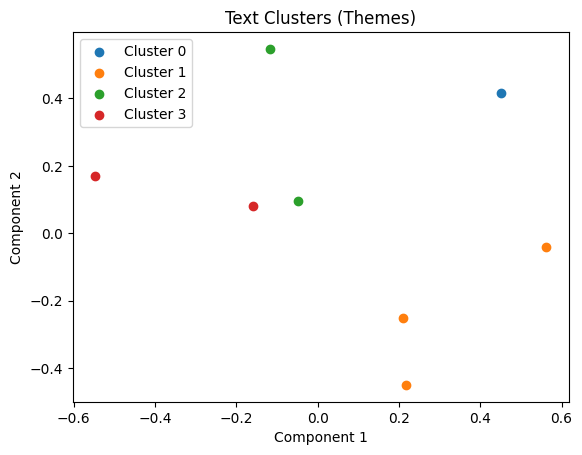

In [36]:
# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# Plot
for i in range(n_clusters):
    points = reduced[labels == i]
    plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {i}")

plt.legend()
plt.title("Text Clusters (Themes)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

### Automatic keyword summaries

In [37]:
for label, docs in clusters.items():
    vectorizer = CountVectorizer(stop_words="english")
    X = vectorizer.fit_transform(docs)

    word_counts = np.asarray(X.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()

    top_words = [words[i] for i in word_counts.argsort()[-5:]]

    print(f"\nCluster {label} keywords: {top_words}")


Cluster 2 keywords: ['consultant', 'team', 'understand', 'didn', 'doctors']

Cluster 1 keywords: ['able', 'wish', 'really', 'time', 'staff']

Cluster 5 keywords: ['like', 'bad', 'doesn', 'really', 'food']

Cluster 0 keywords: ['use', 'using', 'appointment', 'book', 'wasn']

Cluster 3 keywords: ['way', 'sure', 'received', 'like', 'really']

Cluster 4 keywords: ['wrong', 'didn', 'english', 'hospital', 'dad']
